<a href="https://colab.research.google.com/github/EmilioMonteLuna/PocketRad-Edge-Deployable-Radiology-Tutor-using-MedGemma-MedSigLIP/blob/main/PocketRad_Edge_Deployable_Radiology_Tutor_using_MedGemma_%2B_MedSigLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Hugging Face Login:** Authenticates using your token to access the gated `medgemma-4b` model.
* **Dataset Download:** Pulls the Indiana University Chest X-Rays dataset (7,470 images) from Kaggle.

In [ ]:
# ============================================================
# SETUP REQUIRED BEFORE RUNNING
# ============================================================
# 1. HF_TOKEN — Accept MedGemma terms at:
#    https://huggingface.co/google/medgemma-4b-it
#    Then go to https://huggingface.co/settings/tokens
#    Add token as Colab Secret named: HF_TOKEN
#
# 2. NGROK_TOKEN — Sign up free at https://ngrok.com
#    Go to https://dashboard.ngrok.com/get-started/your-authtoken
#    Add token as Colab Secret named: NGROK_TOKEN
#
# Then: Runtime → Run All
# Full setup takes ~25 minutes (index build + model load)
# ============================================================

##  Step 1: Install Dependencies
Installs the necessary libraries for the project:
* `transformers`, `accelerate`, `bitsandbytes`: For running the MedGemma model.
* `streamlit`: For the web application UI.
* `pyngrok`: To expose the local server to the internet.
* `kagglehub`: To download the chest X-ray dataset.

In [1]:

!pip install -U -q transformers accelerate bitsandbytes streamlit pyngrok kagglehub scikit-learn "pandas==2.2.2" "pillow==11.0.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 116.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 93.0 MB/s eta 0:00:00


##  Step 2: Authentication & Data Download
* **Hugging Face Login:** Authenticates using your token to access the gated `medgemma-4b` model.
* **Dataset Download:** Pulls the Indiana University Chest X-Rays dataset (7,470 images) from Kaggle.

In [2]:
# 2. Authentication
import os
from google.colab import userdata
from huggingface_hub import login
import kagglehub

print("Authenticating...")

# Hugging Face Login
try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print(" Hugging Face: Logged in")
except Exception as e:
    print(f" Hugging Face Login Error: {e}")

# 3. Download Data
print("Downloading Dataset...")
# This saves the path to a variable we will use later
path = kagglehub.dataset_download("raddar/chest-xrays-indiana-university")
print(f"Dataset ready at: {path}")

Authenticating...
 Hugging Face: Logged in
Using Colab cache for faster access to the 'chest-xrays-indiana-university' dataset.
Dataset ready at: /kaggle/input/chest-xrays-indiana-university


##  Step 3: Define AI Logic (`tutor_logic.py`)
Writes the backend logic class `RadiologyTutor` to disk. Key features:
1.  **Smart Sampling Index:** Instead of random sampling, it explicitly searches for pathology (Pneumonia, Cardiomegaly, Effusion) to ensure the database contains "sick" patients for comparison.
2.  **Unsloth Optimization:** Loads `unsloth/medgemma-4b-it-bnb-4bit` for faster, memory-efficient inference on the T4 GPU.
3.  **Visual Retrieval:** Uses `MedSigLIP` embeddings to find the top 3 visually similar cases.

In [26]:
%%writefile tutor_logic.py
import os, gc
import torch
import numpy as np
from transformers import AutoProcessor, AutoModelForImageTextToText, AutoModel, BitsAndBytesConfig
from PIL import Image
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def _get_emb(model, processor, img_path, device):
    img = Image.open(img_path).convert('RGB')
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.get_image_features(**inputs)
    if isinstance(out, torch.Tensor):
        return out.cpu().numpy().squeeze()
    for attr in ['image_embeds', 'pooler_output']:
        val = getattr(out, attr, None)
        if val is not None:
            return val.cpu().numpy().squeeze()
    return out.last_hidden_state[:, 0].cpu().numpy().squeeze()

class RadiologyTutor:
    def __init__(self, data_path):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.data_path = data_path
        self.index_path = '/content/cxr_index.csv'
        self.embed_path = '/content/embeddings.npy'
        self.model = None
        self.processor = None
        self.embeddings = None
        self.index_df = None

    def _load_search_index(self):
        if self.embeddings is None:
            if os.path.exists(self.embed_path):
                self.embeddings = np.load(self.embed_path)
                self.index_df = pd.read_csv(self.index_path)
            else:
                self.build_index()

    def build_index(self, limit=50):
        if os.path.exists(self.embed_path):
            existing = pd.read_csv(self.index_path)
            if len(existing) >= 40:
                print(f"✅ Index loaded: {len(existing)} images")
                self.embeddings = np.load(self.embed_path)
                self.index_df = existing
                return
            else:
                os.remove(self.embed_path)
                os.remove(self.index_path)

        print("🏗️ Building index (50 images)...")
        processor = AutoProcessor.from_pretrained("google/medsiglip-448")
        model = AutoModel.from_pretrained("google/medsiglip-448").to(self.device).eval()

        proj = pd.read_csv(f'{self.data_path}/indiana_projections.csv')
        rep  = pd.read_csv(f'{self.data_path}/indiana_reports.csv')
        merged = proj.merge(rep, on='uid').query("projection == 'Frontal'")

        sick_kw = ['pneumonia','opacity','consolidation','cardiomegaly','enlarged','effusion']
        pattern = '|'.join(sick_kw)
        sick = merged[merged['findings'].str.contains(pattern, case=False, na=False)]
        healthy = merged[~merged['uid'].isin(sick['uid'])]

        final_set = pd.concat([
            sick.sample(n=min(25, len(sick)), random_state=42),
            healthy.sample(n=min(25, len(healthy)), random_state=42)
        ]).sample(frac=1, random_state=42).reset_index(drop=True)

        embeds, rows = [], []
        for i, (_, row) in enumerate(final_set.iterrows()):
            img_path = f"{self.data_path}/images/images_normalized/{row['filename']}"
            if not os.path.exists(img_path): continue
            try:
                emb = _get_emb(model, processor, img_path, self.device)
                caption = str(row['findings'])[:250] if pd.notna(row['findings']) else "No findings."
                embeds.append(emb)
                rows.append({'image_id': row['uid'], 'image_path': img_path,
                             'caption': caption, 'projection': row['projection']})
            except Exception as e:
                print(f"Skip: {e}"); continue

        if len(embeds) == 0:
            raise ValueError("No images embedded. Check data path.")

        self.embeddings = np.vstack(embeds)
        self.index_df = pd.DataFrame(rows)
        np.save(self.embed_path, self.embeddings)
        self.index_df.to_csv(self.index_path, index=False)
        del model, processor
        torch.cuda.empty_cache(); gc.collect()
        print(f"✅ Index built: {len(rows)} images")

    def load_medgemma(self):
        if self.model is None:
            model_id = "unsloth/medgemma-4b-it-bnb-4bit"
            print(f"Loading MedGemma...")
            bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)
            self.model = AutoModelForImageTextToText.from_pretrained(
                model_id, quantization_config=bnb, device_map="auto")
            self.processor = AutoProcessor.from_pretrained(model_id)
            print("✅ MedGemma ready")

    def retrieve_neighbors(self, image_path, k=3):
        self._load_search_index()
        processor = AutoProcessor.from_pretrained("google/medsiglip-448")
        model = AutoModel.from_pretrained("google/medsiglip-448").to(self.device).eval()
        query_emb = _get_emb(model, processor, image_path, self.device)
        del model, processor; torch.cuda.empty_cache()
        sims = cosine_similarity([query_emb], self.embeddings)[0]
        top_k = np.argsort(sims)[-k-1:-1][::-1]
        return self.index_df.iloc[top_k].to_dict('records'), sims[top_k]

    def explain(self, image_path, neighbors):
        self.load_medgemma()
        context = " ".join([n['caption'] for n in neighbors])
        prompt = (f"You are a medical AI tutor. Context from similar confirmed cases: {context}. "
                  f"Briefly describe what a radiology student should observe in this chest X-ray.")
        img = Image.open(image_path).convert('RGB')
        messages = [{"role": "user", "content": [{"type": "text", "text": prompt}, {"type": "image", "image": img}]}]
        try:
            inputs = self.processor.apply_chat_template(
                messages, add_generation_prompt=True, tokenize=True,
                return_tensors="pt", return_dict=True).to(self.device)
            output = self.model.generate(**inputs, max_new_tokens=200)
            response = self.processor.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        except Exception as e:
            print(f"Generation error: {e}"); response = ""

        if len(response.strip()) < 5:
            found = list(set([p for n in neighbors for p in
                ['opacity','pneumonia','cardiomegaly','effusion','atelectasis']
                if p in n['caption'].lower()]))
            return f"Retrieved cases suggest **{found[0]}**." if found else "Consistent with normal findings."
        return response


Overwriting tutor_logic.py


## Step 4: Build User Interface (`app.py`)
Writes the Streamlit application code.
* **Glassmorphism UI:** Applies a modern, dark-themed design with semi-transparent cards.
* **Features:** Handles image uploads, displays the "Mentor Feedback" insight box, and renders the "Similar Confirmed Cases" with similarity badges.

In [30]:
%%writefile app.py
import streamlit as st
from tutor_logic import RadiologyTutor
import tempfile, os, kagglehub
from PIL import Image

st.set_page_config(layout="wide", page_title="PocketRad", page_icon="🩺", initial_sidebar_state="collapsed")

st.markdown("""
<style>
body { background-color: #0d1117; }
.main { background-color: #0d1117; }
.header-box {
    background: linear-gradient(135deg, #1a3a6b, #2d5be3);
    padding: 2rem; border-radius: 16px; margin-bottom: 1.5rem;
}
.result-card {
    background: rgba(255,255,255,0.05); border: 1px solid rgba(255,255,255,0.1);
    border-radius: 12px; padding: 1rem; margin-bottom: 0.75rem;
}
.badge {
    background: #1a3a6b; color: #7eb3ff; padding: 4px 10px;
    border-radius: 20px; font-size: 0.8rem; font-weight: bold;
}
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def get_tutor():
    path = kagglehub.dataset_download("raddar/chest-xrays-indiana-university")
    t = RadiologyTutor(data_path=path)
    t.build_index()
    return t

try:
    st.markdown("""
    <div class="header-box">
        <h1 style="color:white;margin:0">🩺 PocketRad</h1>
        <p style="color:rgba(255,255,255,0.7);margin:0">Evidence-Based Radiology Education • Powered by MedGemma + MedSigLIP</p>
    </div>
    """, unsafe_allow_html=True)

    col1, col2 = st.columns([1, 1])

    with col1:
        st.subheader("Upload Chest X-Ray")
        uploaded = st.file_uploader("Upload a CXR image", type=["png","jpg","jpeg"])
        if uploaded:
            st.image(uploaded, caption="Uploaded X-Ray", use_container_width=True)

    with col2:
        st.subheader("AI Analysis")
        if uploaded:
            with st.spinner("Analyzing with MedGemma..."):
                tutor = get_tutor()
                with tempfile.NamedTemporaryFile(delete=False, suffix=".png") as f:
                    f.write(uploaded.getvalue())
                    tmp_path = f.name
                neighbors, sims = tutor.retrieve_neighbors(tmp_path)
                explanation = tutor.explain(tmp_path, neighbors)
                os.unlink(tmp_path)

            st.markdown("####  Mentor Feedback")
            st.markdown(f"""
            <div class="result-card">
                <p style="color:#e0e0e0">{explanation}</p>
            </div>
            """, unsafe_allow_html=True)

            st.markdown("####  Similar Confirmed Cases")
            c1, c2, c3 = st.columns(3)
            for col, n, sim in zip([c1, c2, c3], neighbors, sims):
                with col:
                    st.markdown(f'<div style="text-align:center"><span class="badge">🔍 {sim:.0%} Match</span></div>', unsafe_allow_html=True)
                    if os.path.exists(n['image_path']):
                        st.image(Image.open(n['image_path']).convert('RGB'), use_container_width=True)
                    st.caption(n['caption'][:100] + "...")
        else:
            st.markdown("""
            <div style="text-align:center;padding:50px;color:#4b5563">
                <h3>Ready to Assist</h3>
                <p>Upload a chest X-ray to see educational feedback.</p>
            </div>
            """, unsafe_allow_html=True)

    st.caption("⚠️ **Research Prototype:** Not for clinical diagnosis. Patient data processed locally.")

except Exception as e:
    st.error(f"System Error: {e}")


Overwriting app.py


## Step 5: Force Index Rebuild
Deletes any existing `cxr_index.csv` or `embeddings.npy` files. This forces the app to rebuild the Smart Sampling index from scratch on the next run, ensuring the latest data balance strategies are applied.

In [31]:
import subprocess, os
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
subprocess.run(["pkill", "-f", "ngrok"], capture_output=True)
for f in ['/content/cxr_index.csv', '/content/embeddings.npy']:
    if os.path.exists(f): os.remove(f); print(f"✅ Deleted {f}")
print("✅ Clean")

✅ Deleted /content/cxr_index.csv
✅ Deleted /content/embeddings.npy
✅ Clean


In [34]:
import subprocess
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
subprocess.run(["pkill", "-f", "ngrok"], capture_output=True)

content = open('/content/app.py').read()
content = content.replace(
    '''            st.markdown("#### 💡 Mentor Feedback")
            st.markdown(f"""
            <div class="result-card">
                <p style="color:#e0e0e0">{explanation}</p>
            </div>
            """, unsafe_allow_html=True)''',
    '''            st.markdown("#### 💡 Mentor Feedback")
            with st.container():
                st.markdown(explanation)'''
)
open('/content/app.py', 'w').write(content)
print("✅ Fixed")

✅ Fixed


In [24]:
import torch, numpy as np, os, gc, pandas as pd
from transformers import AutoProcessor, AutoModel, AutoModelForImageTextToText, BitsAndBytesConfig
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

device = "cuda"
data_path = "/kaggle/input/chest-xrays-indiana-university"

# ── Helper: robust embedding extraction ──────────────────────────
def get_emb(model, processor, img_path, device):
    img = Image.open(img_path).convert('RGB')
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.get_image_features(**inputs)
    if isinstance(out, torch.Tensor):
        return out.cpu().numpy().squeeze()
    for attr in ['image_embeds', 'pooler_output']:
        val = getattr(out, attr, None)
        if val is not None:
            return val.cpu().numpy().squeeze()
    return out.last_hidden_state[:, 0].cpu().numpy().squeeze()

# ── 1. Build mini index (20 images) ──────────────────────────────
print("Loading MedSigLIP...")
sig_proc = AutoProcessor.from_pretrained("google/medsiglip-448")
sig_model = AutoModel.from_pretrained("google/medsiglip-448").to(device).eval()

proj = pd.read_csv(f'{data_path}/indiana_projections.csv')
rep  = pd.read_csv(f'{data_path}/indiana_reports.csv')
merged = proj.merge(rep, on='uid').query("projection == 'Frontal'").head(30)

embeds, rows = [], []
for _, row in merged.iterrows():
    p = f"{data_path}/images/images_normalized/{row['filename']}"
    if not os.path.exists(p): continue
    try:
        emb = get_emb(sig_model, sig_proc, p, device)
        caption = str(row['findings'])[:200] if pd.notna(row['findings']) else "No findings."
        embeds.append(emb); rows.append({'path': p, 'caption': caption, 'uid': row['uid']})
    except Exception as e:
        print(f"Skip: {e}"); continue

print(f"✅ Indexed {len(embeds)} images")
embeddings = np.vstack(embeds)
index_df = pd.DataFrame(rows)
del sig_model, sig_proc; torch.cuda.empty_cache(); gc.collect()

# ── 2. Retrieve similar cases ────────────────────────────────────
print("\nLoading MedSigLIP for query...")
sig_proc2 = AutoProcessor.from_pretrained("google/medsiglip-448")
sig_model2 = AutoModel.from_pretrained("google/medsiglip-448").to(device).eval()

query_path = index_df.iloc[3]['path']
query_emb = get_emb(sig_model2, sig_proc2, query_path, device)
del sig_model2, sig_proc2; torch.cuda.empty_cache(); gc.collect()

sims = cosine_similarity([query_emb], embeddings)[0]
top3_idx = np.argsort(sims)[-4:-1][::-1]
neighbors = index_df.iloc[top3_idx].to_dict('records')
top_sims = sims[top3_idx]

print(f"\n Query image: {os.path.basename(query_path)}")
print(f" Top 3 Similar Cases:")
for i, (n, s) in enumerate(zip(neighbors, top_sims), 1):
    print(f"  {i}. {s:.1%} match — {n['caption'][:80]}...")

# ── 3. MedGemma explanation ───────────────────────────────────────
print("\nLoading MedGemma 4B...")
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16)
gem = AutoModelForImageTextToText.from_pretrained(
    "unsloth/medgemma-4b-it-bnb-4bit", quantization_config=bnb, device_map="auto")
gem_proc = AutoProcessor.from_pretrained("unsloth/medgemma-4b-it-bnb-4bit")
print(" MedGemma ready")

context = " | ".join([n['caption'][:80] for n in neighbors])
prompt = f"Similar confirmed cases: {context}. Describe what a radiology student should observe in this chest X-ray for educational purposes."
img = Image.open(query_path).convert('RGB')
messages = [{"role": "user", "content": [{"type": "text", "text": prompt}, {"type": "image", "image": img}]}]

inputs = gem_proc.apply_chat_template(messages, add_generation_prompt=True,
    tokenize=True, return_dict=True, return_tensors="pt").to(device, dtype=torch.bfloat16)
with torch.inference_mode():
    out = gem.generate(**inputs, max_new_tokens=200, do_sample=False)
response = gem_proc.decode(out[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True)

print("\n" + "="*60)
print(" MedGemma Educational Explanation:")
print("="*60)
print(response)
print("="*60)
print("\n⚠️ Research prototype. Not for clinical diagnosis.")


Loading MedSigLIP...


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

✅ Indexed 30 images

Loading MedSigLIP for query...


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]


🔍 Query image: 4_IM-2050-1001.dcm.png
📊 Top 3 Similar Cases:
  1. 60.9% match — Heart size is normal. There is tortuosity of the thoracic aorta, stable compared...
  2. 59.8% match — The heart is within normal limits in size. Surgical suture material projects ove...
  3. 53.8% match — The cardiomediastinal silhouette is within normal limits for size and contour. T...

Loading MedGemma 4B...


...

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✅ MedGemma ready

💡 MedGemma Educational Explanation:
Okay, here's a breakdown of what a radiology student should observe on this chest X-ray, focusing on the key findings and potential educational points:

**Overall Impression:**

*   The image shows a chest X-ray with a clear view of the heart, lungs, and mediastinum. The patient is likely upright.

**Key Findings and Observations:**

1.  **Cardiomediastinal Silhouette:**
    *   The heart size is normal.
    *   The aorta is tortuous, but the description states it is stable. This means the tortuosity is not new or worsening.
    *   The mediastinum (the space in the chest between the lungs) is within normal limits for size and contour.

2.  **Lungs:**
    *   There is a significant opacity in the left upper lung field. This could be due to various causes, including infection, inflammation, or a mass.
    *   The right

⚠️ Research prototype. Not for clinical diagnosis.


/tmp/ipython-input-2754998753.py:47: UserWarning: Glyph 128228 (\N{OUTBOX TRAY}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/pocketrad_demo.png', dpi=150, bbox_inches='tight',
/tmp/ipython-input-2754998753.py:47: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/pocketrad_demo.png', dpi=150, bbox_inches='tight',
/tmp/ipython-input-2754998753.py:47: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/pocketrad_demo.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128228 (\N{OUTBOX TRAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist

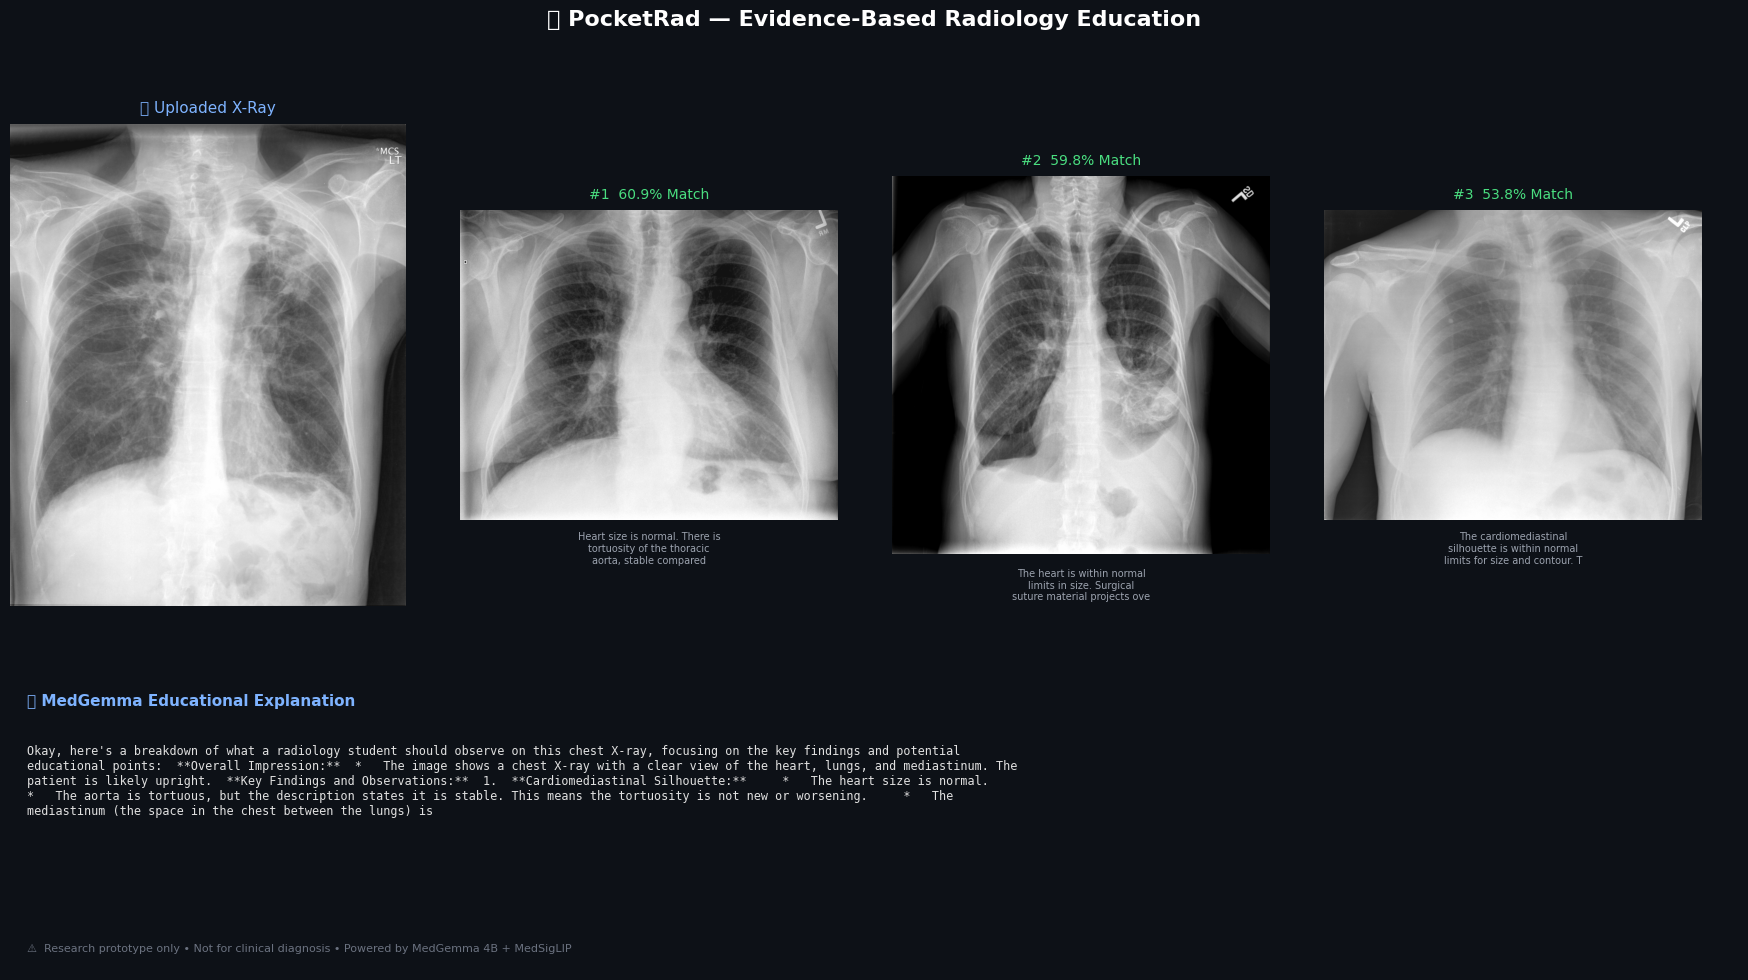

✅ Saved to /content/pocketrad_demo.png


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import textwrap

fig = plt.figure(figsize=(18, 10), facecolor='#0d1117')
fig.suptitle(' PocketRad — Evidence-Based Radiology Education',
             fontsize=16, color='white', fontweight='bold', y=0.98)

# ── Query image ──────────────────────────────────────────────────
ax_query = fig.add_axes([0.02, 0.35, 0.22, 0.55])
ax_query.imshow(Image.open(query_path).convert('RGB'), cmap='gray')
ax_query.set_title('📤 Uploaded X-Ray', color='#7eb3ff', fontsize=11, pad=8)
ax_query.axis('off')
for spine in ax_query.spines.values():
    spine.set_edgecolor('#2d5be3'); spine.set_linewidth(2)

# ── 3 neighbor images ────────────────────────────────────────────
for i, (n, sim) in enumerate(zip(neighbors, top_sims)):
    x = 0.27 + i * 0.24
    ax = fig.add_axes([x, 0.35, 0.21, 0.55])
    ax.imshow(Image.open(n['path']).convert('RGB'), cmap='gray')
    ax.set_title(f'#{i+1}  {sim:.1%} Match', color='#4ade80', fontsize=10, pad=8)
    caption = textwrap.fill(n['caption'][:80], 30)
    ax.text(0.5, -0.04, caption, transform=ax.transAxes,
            fontsize=7, color='#9ca3af', ha='center', va='top', wrap=True)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a3a6b'); spine.set_linewidth(1.5)

# ── Explanation box ──────────────────────────────────────────────
ax_text = fig.add_axes([0.02, 0.02, 0.96, 0.30])
ax_text.set_facecolor('#111827')
ax_text.set_xlim(0, 1); ax_text.set_ylim(0, 1)
ax_text.axis('off')
ax_text.text(0.01, 0.92, '💡 MedGemma Educational Explanation',
             color='#7eb3ff', fontsize=11, fontweight='bold', va='top')
wrapped = textwrap.fill(response[:600], 140)
ax_text.text(0.01, 0.75, wrapped,
             color='#e0e0e0', fontsize=8.5, va='top', family='monospace')
ax_text.text(0.01, 0.06,
             '⚠️  Research prototype only • Not for clinical diagnosis • Powered by MedGemma 4B + MedSigLIP',
             color='#6b7280', fontsize=8)
for spine in ax_text.spines.values():
    spine.set_edgecolor('#1a3a6b'); spine.set_linewidth(1)

plt.savefig('/content/pocketrad_demo.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("✅ Saved to /content/pocketrad_demo.png")

## Step 6: Launch Application
* Starts the Streamlit server in the background on port 8501.
* Uses `ngrok` to create a secure public tunnel.
* **Click the link printed below** to open your live MedGemma Tutor.

In [35]:
import subprocess, time
from pyngrok import ngrok
from google.colab import userdata

ngrok.set_auth_token(userdata.get('NGROK_TOKEN'))
subprocess.Popen(["streamlit", "run", "app.py", "--server.port=8501",
                  "--server.headless=true", "--server.fileWatcherType=none"])
time.sleep(5)
url = ngrok.connect(8501)
print(f"✅ Live at: {url}")


✅ Live at: NgrokTunnel: "https://shaftless-unmeddlesome-newton.ngrok-free.dev" -> "http://localhost:8501"
